# Reducción de dimensionalidad con t-SNE y UMAP

Ejemplo de aplicación de t-SNE y UMAP para reducir la dimensionalidad y visualizar un conjunto de datos.

Se utiliza el conjunto de datos MNIST de dígitos escritos a mano. Cada imagen es de 28×28 píxeles y cada píxel se considera una variable, por lo que cada ejemplo tiene 784 dimensiones.

En este notebook se estudia el efecto de perplexity en t-SNE y de n_neighbors y min_dist en UMAP. También se compara la preservación de vecindarios mediante trustworthiness.


In [1]:
import os
import gzip
import pickle
import time

import os
import warnings

os.environ["LOKY_MAX_CPU_COUNT"] = "1"
warnings.filterwarnings("ignore", message=r"Could not find the number of physical cores.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE, trustworthiness
from umap import UMAP

%matplotlib inline


## 1. Carga y exploración de los datos

El archivo mnist.pkl.gz contiene tres particiones:

Entrenamiento: 50.000 ejemplos

Validación: 10.000 ejemplos

Prueba: 10.000 ejemplos

Para estudiar t-SNE utilizaremos una submuestra del conjunto de entrenamiento. Esto es conveniente porque t-SNE es computacionalmente más costoso que PCA y su uso más habitual es la visualización exploratoria.


In [2]:
# Cargamos el conjunto de datos MNIST
ruta_archivo = os.path.join(os.getcwd(), 'mnist.pkl.gz')

with gzip.open(ruta_archivo, 'rb') as f:
    train_set, validation_set, test_set = pickle.load(f, encoding='latin1')

X_train, y_train = train_set[0], train_set[1]
X_validation, y_validation = validation_set[0], validation_set[1]
X_test, y_test = test_set[0], test_set[1]


In [3]:
# Verificamos las dimensiones de cada partición
print("Entrenamiento: %d ejemplos con %d características" % X_train.shape)
print("Validación:    %d ejemplos con %d características" % X_validation.shape)
print("Prueba:        %d ejemplos con %d características" % X_test.shape)


Entrenamiento: 50000 ejemplos con 784 características
Validación:    10000 ejemplos con 784 características
Prueba:        10000 ejemplos con 784 características


In [4]:
# Convertimos los arreglos a DataFrames y Series de pandas
train_index = range(0, len(X_train))
validation_index = range(len(X_train), len(X_train) + len(X_validation))
test_index = range(len(X_train) + len(X_validation),
                   len(X_train) + len(X_validation) + len(X_test))

X_train = pd.DataFrame(data=X_train, index=train_index)
y_train = pd.Series(data=y_train, index=train_index)

X_validation = pd.DataFrame(data=X_validation, index=validation_index)
y_validation = pd.Series(data=y_validation, index=validation_index)

X_test = pd.DataFrame(data=X_test, index=test_index)
y_test = pd.Series(data=y_test, index=test_index)

X_train.describe()


,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
count,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0,50000.0,50000.0,50000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000739,0.000354,0.000204,0.000090,0.000071,0.000009,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.022778,0.015422,0.012079,0.007217,0.007181,0.001483,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.992188,0.992188,0.988281,0.988281,0.992188,0.242188,0.0,0.0,0.0,0.0


Los píxeles de MNIST ya están en el rango [0, 1]. Como todas las variables representan intensidades de píxeles en la misma escala, no aplicaremos StandardScaler en este ejemplo.


In [5]:
# Las etiquetas corresponden a los dígitos del 0 al 9
y_train.unique()


array([5, 0, 4, 1, 9, 2, 3, 6, 7, 8])

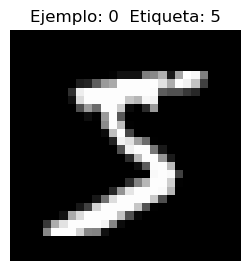

In [6]:
def ver_digito(ejemplo):
    etiqueta = y_train.loc[ejemplo]
    imagen = X_train.loc[ejemplo, :].values.reshape([28, 28])

    plt.figure(figsize=(3, 3))
    plt.title('Ejemplo: %d  Etiqueta: %d' % (ejemplo, etiqueta))
    plt.imshow(imagen, cmap='gray')
    plt.axis('off')
    plt.show()

ver_digito(0)


In [7]:
# Varianza de cada píxel a lo largo de los ejemplos de entrenamiento
varianza_pixeles = X_train.var(axis=0)

n_total = X_train.shape[1]
n_constantes = (varianza_pixeles == 0).sum()
n_casi_constantes = (varianza_pixeles < 0.01).sum()

print("Número total de variables (píxeles):  %d" % n_total)
print("Variables constantes (varianza cero): %d" % n_constantes)
print("Variables con varianza menor a 0.01:   %d" % n_casi_constantes)


Número total de variables (píxeles):  784
Variables constantes (varianza cero): 67
Variables con varianza menor a 0.01:   341


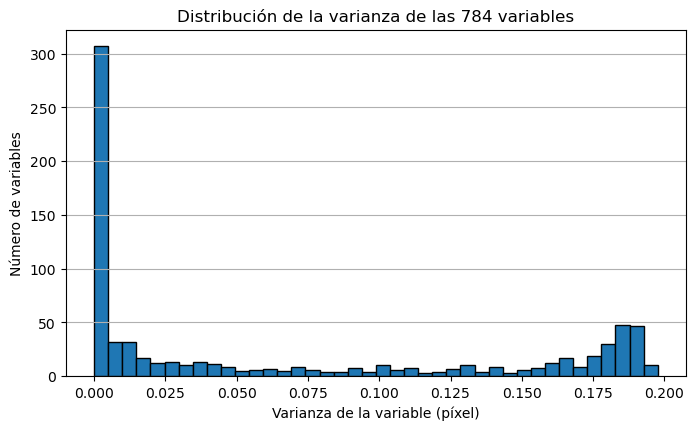

In [8]:
plt.figure(figsize=(8, 4.5))
plt.hist(varianza_pixeles, bins=40, edgecolor='black')
plt.xlabel('Varianza de la variable (píxel)')
plt.ylabel('Número de variables')
plt.title('Distribución de la varianza de las 784 variables')
plt.grid(True, axis='y')
plt.show()


## 2. Preparación de una submuestra para t-SNE y UMAP

t-SNE y UMAP construyen representaciones de menor dimensión a partir de relaciones de vecindad. Para facilitar la ejecución de la práctica utilizaremos una submuestra del conjunto de entrenamiento.

Usaremos una submuestra reproducible de 10.000 observaciones. Las etiquetas no se utilizan para calcular las representaciones; se conservarán solamente para colorear los puntos en las gráficas y facilitar la interpretación.


In [9]:
import warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")

In [10]:
n_muestra = 10000
#semilla = 42
#rng = np.random.default_rng(semilla)
rng = np.random.default_rng()
indices_muestra = rng.choice(X_train.index, size=n_muestra, replace=False)

X_muestra = X_train.loc[indices_muestra].copy()
y_muestra = y_train.loc[indices_muestra].copy()

print("Dimensión de la muestra:", X_muestra.shape)
print("\nDistribución de etiquetas:")
print(y_muestra.value_counts().sort_index())


Dimensión de la muestra: (10000, 784)

Distribución de etiquetas:
0     962
1    1167
2    1011
3     995
4     947
5     917
6    1007
7    1065
8     966
9     963
Name: count, dtype: int64


## 3. t-SNE con una perplexity inicial

t-SNE transforma las distancias del espacio original en probabilidades de similitud y busca una representación de menor dimensión cuyas probabilidades de similitud sean lo más parecidas posible.

En el espacio original se construye la matriz P = [p_ij].

En el espacio reducido se construye la matriz Q = [q_ij].

Las posiciones de los puntos en el espacio reducido se actualizan iterativamente para minimizar la divergencia KL(P || Q).

La perplexity controla aproximadamente la escala del vecindario que t-SNE intenta preservar. Un valor inicial frecuente para exploración es 30.


In [11]:
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', max_iter=1000, random_state=42)

inicio = time.time()
X_tsne = tsne.fit_transform(X_muestra)
tiempo_tsne = time.time() - inicio

X_tsne = pd.DataFrame(X_tsne, index=X_muestra.index, columns=['tSNE_1', 'tSNE_2'])

print("Dimensión original:", X_muestra.shape)
print("Dimensión reducida:", X_tsne.shape)
print("Divergencia KL final: %.4f" % tsne.kl_divergence_)
print("Tiempo de ejecución: %.2f segundos" % tiempo_tsne)


  File "C:\Users\Unimagdalena\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Unimagdalena\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Unimagdalena\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Unimagdale

Dimensión original: (10000, 784)
Dimensión reducida: (10000, 2)
Divergencia KL final: 1.8253
Tiempo de ejecución: 31.33 segundos


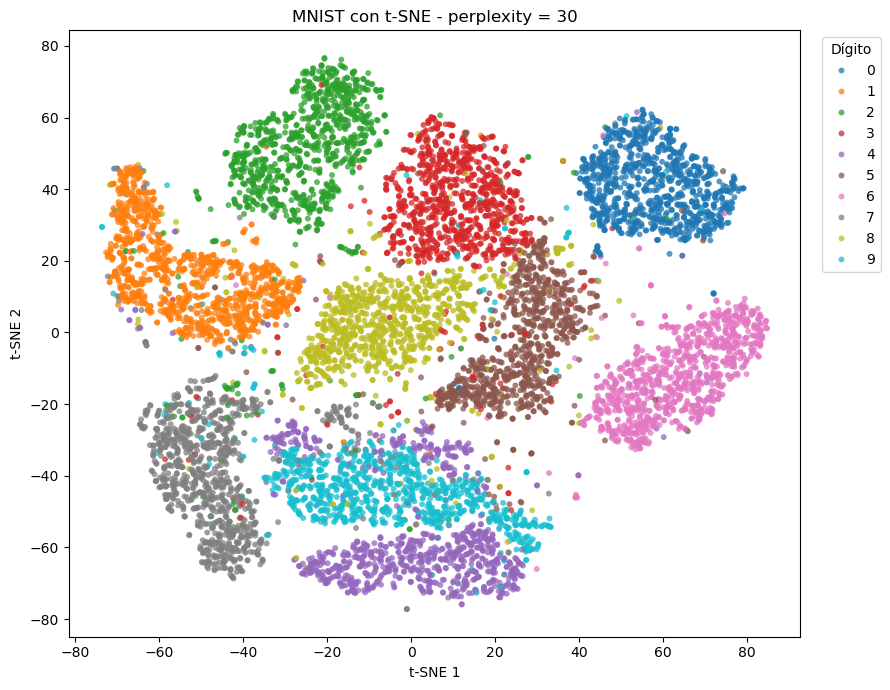

In [12]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=X_tsne['tSNE_1'],
    y=X_tsne['tSNE_2'],
    hue=y_muestra,
    palette='tab10',
    s=18,
    alpha=0.75,
    linewidth=0
)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('MNIST con t-SNE - perplexity = 30')
plt.legend(title='Dígito', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


Los ejes t-SNE 1 y t-SNE 2 no tienen una interpretación directa como variables originales o componentes principales. Lo importante es analizar las relaciones de vecindad entre los puntos.

La distancia entre grupos alejados en el mapa tampoco debe interpretarse como una medida exacta de distancia en el espacio original.


## 4. Comparación de diferentes valores de perplexity

Ahora mantendremos fija la misma muestra de datos, la inicialización y la semilla, y cambiaremos únicamente perplexity.

Esto permite observar cómo cambia la representación cuando t-SNE considera vecindarios más pequeños o más amplios.

Se evaluarán los valores 5, 15, 30 y 50.


In [13]:
valores_perplexity = [5, 15, 30, 50]

resultados_tsne = {}
metricas = []

for p in valores_perplexity:
    print("Calculando t-SNE con perplexity =", p)

    modelo = TSNE(n_components=2, perplexity=p, init='pca', learning_rate='auto', max_iter=1000, random_state=42)

    inicio = time.time()
    embedding = modelo.fit_transform(X_muestra)
    tiempo = time.time() - inicio

    resultados_tsne[p] = embedding

    metricas.append({
        'Perplexity': p,
        'KL final': modelo.kl_divergence_,
        'Tiempo (s)': tiempo
    })

metricas_tsne = pd.DataFrame(metricas)
metricas_tsne


Calculando t-SNE con perplexity = 5
Calculando t-SNE con perplexity = 15
Calculando t-SNE con perplexity = 30
Calculando t-SNE con perplexity = 50


,Perplexity,KL final,Tiempo (s)
0,5,1.956080,25.061669
1,15,1.913718,29.296153
2,30,1.825258,34.171627
3,50,1.724282,43.352772


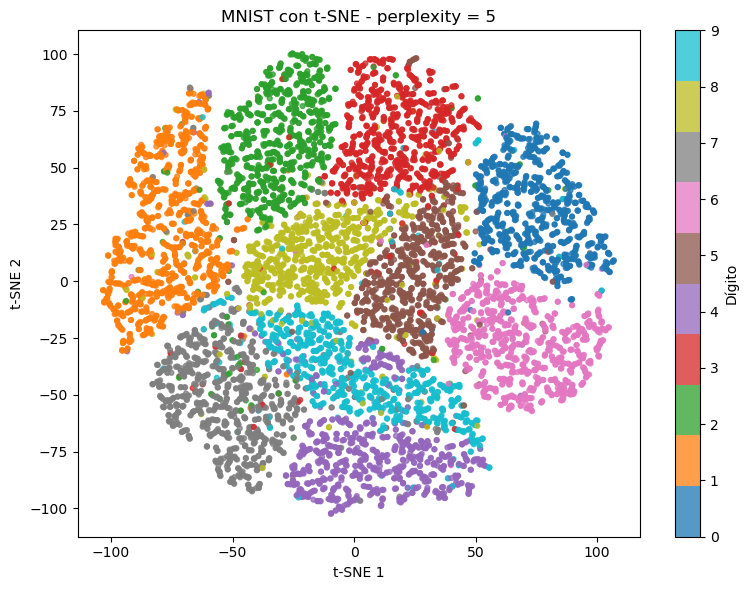

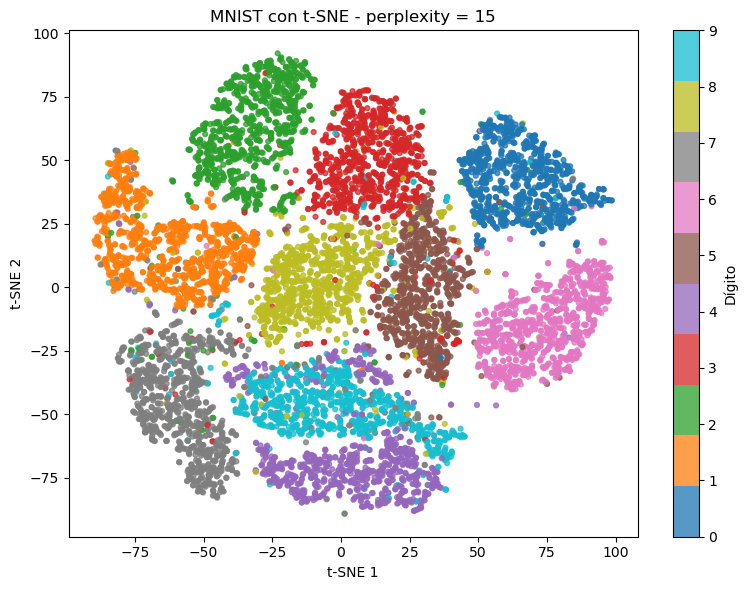

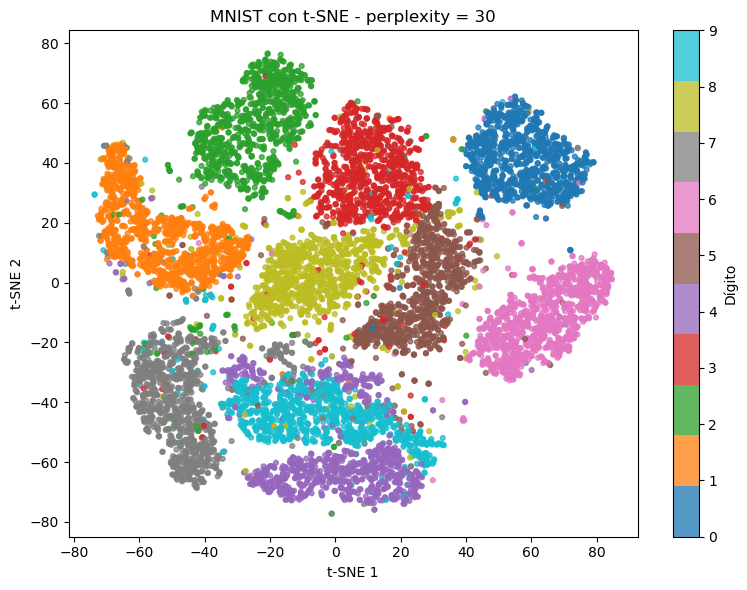

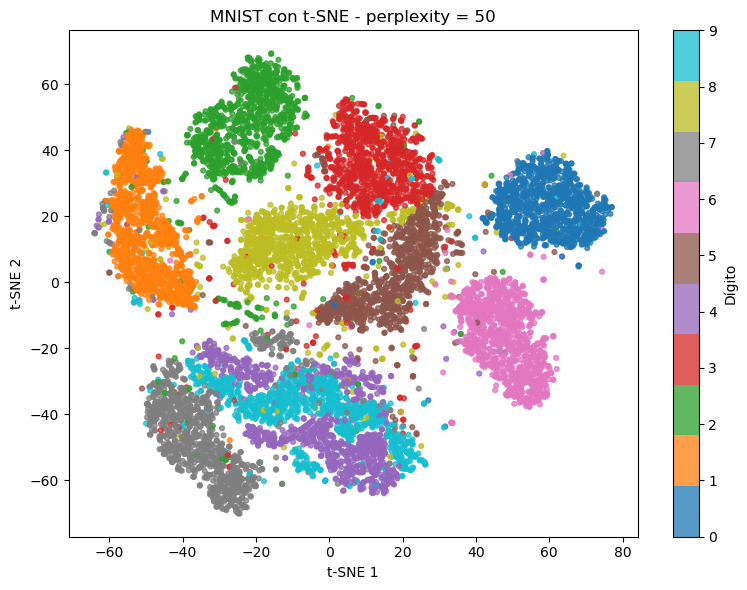

In [14]:
# Visualizamos cada representación por separado
for p in valores_perplexity:
    embedding = resultados_tsne[p]

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y_muestra.values,
        cmap='tab10',
        s=12,
        alpha=0.75
    )

    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title('MNIST con t-SNE - perplexity = %d' % p)

    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.set_label('Dígito')

    plt.tight_layout()
    plt.show()


Al comparar las gráficas conviene revisar qué estructuras permanecen relativamente estables y cuáles cambian al modificar perplexity.

Una perplexity pequeña da más importancia a vecindarios muy locales y puede fragmentar la representación.

Una perplexity mayor incorpora relaciones de vecindad más amplias y puede producir estructuras más suaves.

No debe elegirse el valor únicamente porque una gráfica parezca mostrar grupos más separados.


## 5. Evaluación de la preservación de vecindarios

Como t-SNE busca preservar relaciones locales, podemos complementar la inspección visual con la métrica trustworthiness.

Trustworthiness mide qué tan bien se conservan en el espacio reducido los vecinos del espacio original.

Su valor está entre 0 y 1 y valores más cercanos a 1 indican una mejor preservación de los vecindarios.

Para que el cálculo sea más rápido utilizaremos una submuestra de 2.000 puntos de la representación ya calculada.


In [15]:
n_eval = 2000

rng_eval = np.random.default_rng(123)
posiciones_eval = rng_eval.choice(np.arange(len(X_muestra)), size=n_eval, replace=False)

X_eval = X_muestra.iloc[posiciones_eval].values

trust = []

for p in valores_perplexity:
    embedding_eval = resultados_tsne[p][posiciones_eval]
    valor = trustworthiness(X_eval, embedding_eval, n_neighbors=10)
    trust.append(valor)

metricas_tsne['Trustworthiness'] = trust
metricas_tsne


,Perplexity,KL final,Tiempo (s),Trustworthiness
0,5,1.956080,25.061669,0.943215
1,15,1.913718,29.296153,0.957019
2,30,1.825258,34.171627,0.960671
3,50,1.724282,43.352772,0.961883


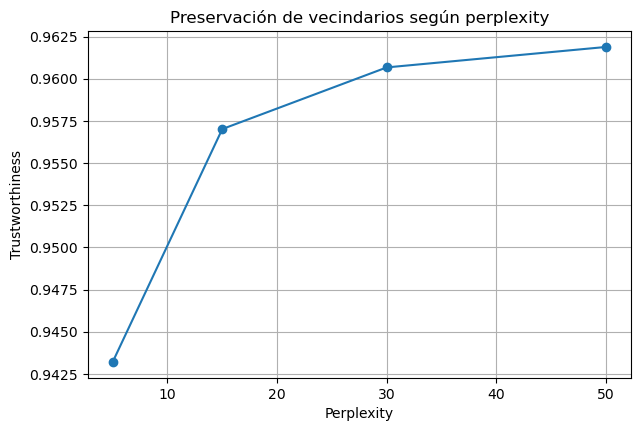

In [16]:
plt.figure(figsize=(7, 4.5))
plt.plot(metricas_tsne['Perplexity'], metricas_tsne['Trustworthiness'], marker='o')
plt.xlabel('Perplexity')
plt.ylabel('Trustworthiness')
plt.title('Preservación de vecindarios según perplexity')
plt.grid(True)
plt.show()

La divergencia KL mostrada por cada ejecución corresponde a la función objetivo optimizada por t-SNE. Sin embargo, al cambiar perplexity también cambia la distribución P del espacio original, por lo que los valores de KL obtenidos con diferentes perplexities no deben interpretarse como una comparación directa y única para seleccionar el mejor valor.

Trustworthiness resulta más útil para comparar cuánto se preservan los vecindarios originales bajo las distintas configuraciones.


## 6. UMAP con una configuración inicial

UMAP construye un grafo ponderado de vecindad en el espacio original y busca una representación de menor dimensión que conserve esas relaciones locales.

En este ejemplo utilizaremos inicialmente:

n_neighbors = 15

min_dist = 0.1

n_components = 2

metric = 'euclidean'

Las etiquetas de MNIST no participan en el cálculo del embedding. Se utilizan solamente para colorear los puntos en la visualización.


In [17]:
import warnings
# Silencia el aviso específico de UMAP sobre n_jobs
warnings.filterwarnings("ignore", message=".*n_jobs value 1 overridden.*")

In [18]:
umap_model = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)

inicio = time.time()
X_umap = umap_model.fit_transform(X_muestra)
tiempo_umap = time.time() - inicio

X_umap = pd.DataFrame(
    X_umap,
    index=X_muestra.index,
    columns=['UMAP_1', 'UMAP_2']
)

print("Dimensión original:", X_muestra.shape)
print("Dimensión reducida:", X_umap.shape)
print("Tiempo de ejecución: %.2f segundos" % tiempo_umap)


Dimensión original: (10000, 784)
Dimensión reducida: (10000, 2)
Tiempo de ejecución: 30.43 segundos


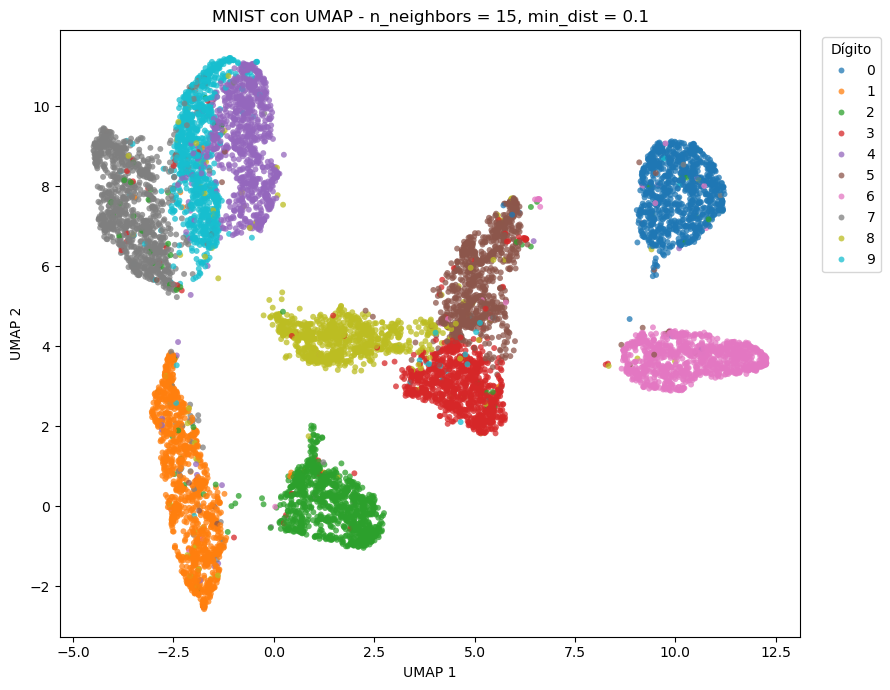

In [19]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=X_umap['UMAP_1'],
    y=X_umap['UMAP_2'],
    hue=y_muestra,
    palette='tab10',
    s=18,
    alpha=0.75,
    linewidth=0
)

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('MNIST con UMAP - n_neighbors = 15, min_dist = 0.1')
plt.legend(title='Dígito', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


Los ejes UMAP 1 y UMAP 2 no tienen una interpretación directa en términos de las variables originales.

La interpretación debe concentrarse en la estructura de vecindad y en la forma en que las observaciones cercanas en el espacio original permanecen relacionadas en el embedding.


## 7. Evaluación de diferentes valores de n_neighbors

El hiperparámetro n_neighbors controla aproximadamente la escala del vecindario utilizado para construir el grafo.

Valores pequeños dan mayor importancia a estructuras muy locales.

Valores mayores permiten incorporar relaciones de vecindad más amplias.

Mantendremos fijo min_dist = 0.1 y evaluaremos los valores 5, 15, 30 y 50.


In [20]:
valores_neighbors = [5, 15, 30, 50]

resultados_umap_neighbors = {}
metricas_umap_neighbors = []

for k in valores_neighbors:
    print("Calculando UMAP con n_neighbors =", k)

    modelo = UMAP(
        n_components=2,
        n_neighbors=k,
        min_dist=0.1,
        metric='euclidean',
        random_state=42
    )

    inicio = time.time()
    embedding = modelo.fit_transform(X_muestra)
    tiempo = time.time() - inicio

    resultados_umap_neighbors[k] = embedding

    metricas_umap_neighbors.append({
        'n_neighbors': k,
        'Tiempo (s)': tiempo
    })

metricas_umap_neighbors = pd.DataFrame(metricas_umap_neighbors)
metricas_umap_neighbors


Calculando UMAP con n_neighbors = 5
Calculando UMAP con n_neighbors = 15
Calculando UMAP con n_neighbors = 30
Calculando UMAP con n_neighbors = 50


,n_neighbors,Tiempo (s)
0,5,8.156401
1,15,12.167774
2,30,16.043904
3,50,21.032534


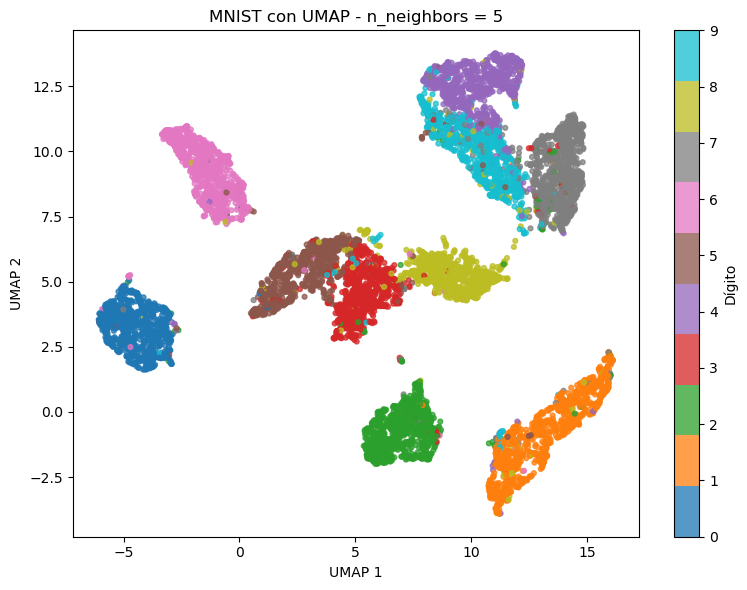

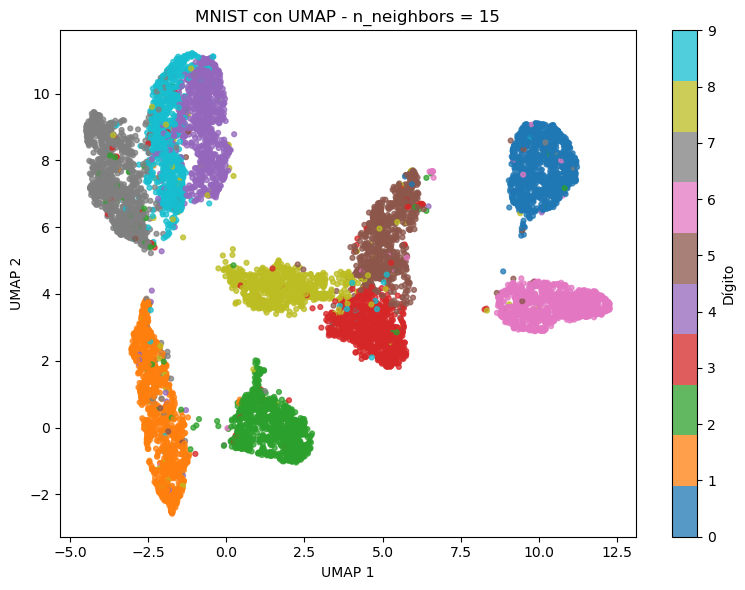

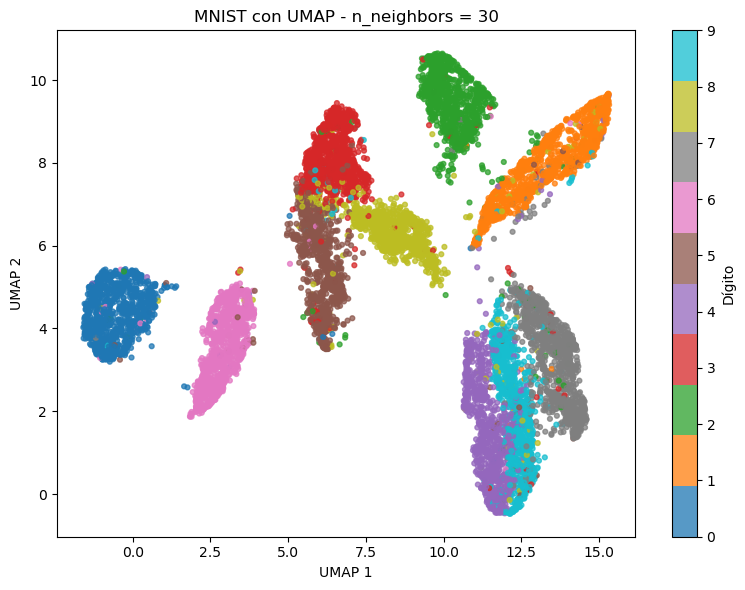

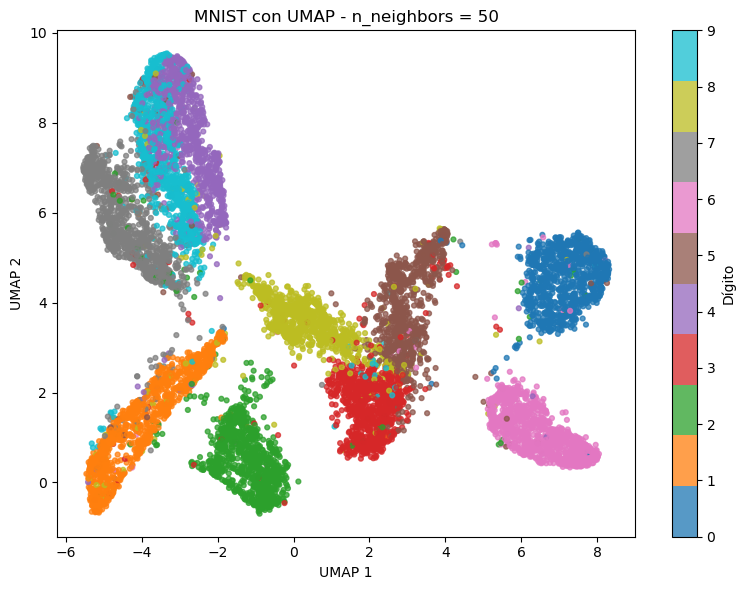

In [21]:
for k in valores_neighbors:
    embedding = resultados_umap_neighbors[k]

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y_muestra.values,
        cmap='tab10',
        s=12,
        alpha=0.75
    )

    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.title('MNIST con UMAP - n_neighbors = %d' % k)

    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.set_label('Dígito')

    plt.tight_layout()
    plt.show()


Al comparar las representaciones conviene observar qué estructuras permanecen estables al modificar n_neighbors.

Un valor pequeño puede resaltar grupos locales muy específicos.

Un valor mayor puede favorecer una representación más integrada de estructuras amplias.

No debe seleccionarse el valor solamente porque produzca grupos visualmente más separados.


## 8. Evaluación de diferentes valores de min_dist

El hiperparámetro min_dist controla qué tan cerca pueden ubicarse los puntos en el embedding.

Valores pequeños permiten formar regiones más compactas.

Valores grandes tienden a distribuir los puntos de manera más extendida.

Mantendremos fijo n_neighbors = 15 y evaluaremos diferentes valores de min_dist.


In [22]:
valores_min_dist = [0.0, 0.1, 0.5, 0.9]

resultados_umap_min_dist = {}
metricas_umap_min_dist = []

for d in valores_min_dist:
    print("Calculando UMAP con min_dist =", d)

    modelo = UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=d,
        metric='euclidean',
        random_state=42
    )

    inicio = time.time()
    embedding = modelo.fit_transform(X_muestra)
    tiempo = time.time() - inicio

    resultados_umap_min_dist[d] = embedding

    metricas_umap_min_dist.append({
        'min_dist': d,
        'Tiempo (s)': tiempo
    })

metricas_umap_min_dist = pd.DataFrame(metricas_umap_min_dist)
metricas_umap_min_dist


Calculando UMAP con min_dist = 0.0
Calculando UMAP con min_dist = 0.1
Calculando UMAP con min_dist = 0.5
Calculando UMAP con min_dist = 0.9


,min_dist,Tiempo (s)
0,0.0,11.450918
1,0.1,11.949910
2,0.5,11.782797
3,0.9,11.828450


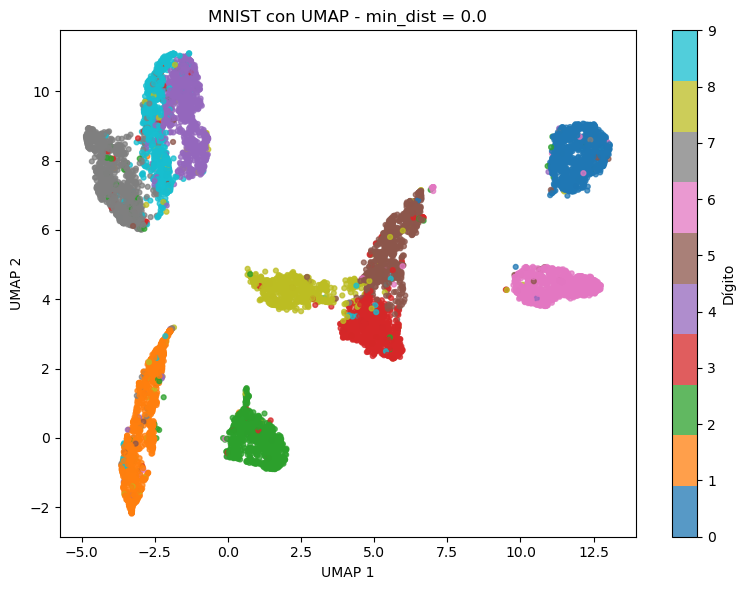

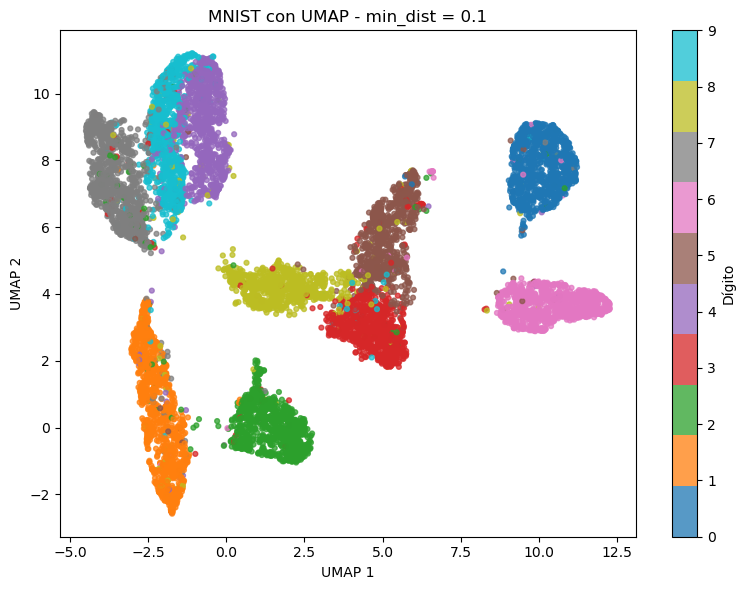

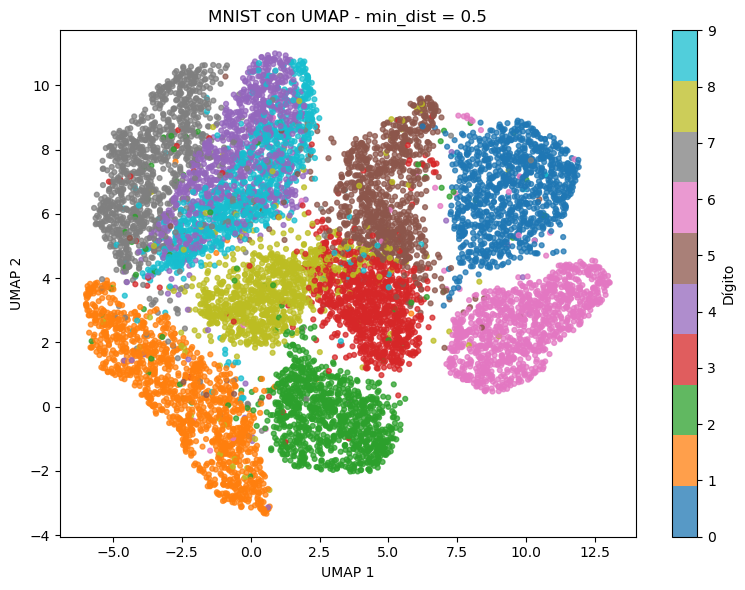

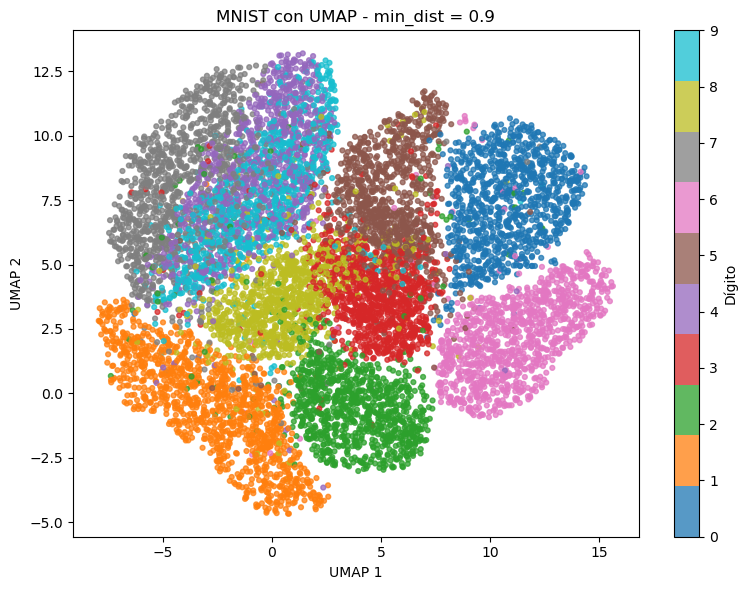

In [23]:
for d in valores_min_dist:
    embedding = resultados_umap_min_dist[d]

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y_muestra.values,
        cmap='tab10',
        s=12,
        alpha=0.75
    )

    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.title('MNIST con UMAP - min_dist = %.1f' % d)

    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.set_label('Dígito')

    plt.tight_layout()
    plt.show()


## 9. Evaluación de la preservación de vecindarios con UMAP

Utilizaremos nuevamente trustworthiness para medir qué tan bien se conservan los vecinos del espacio original en cada representación UMAP.

Se utilizarán las mismas 2.000 observaciones empleadas anteriormente para evaluar t-SNE.


In [24]:
trust_neighbors = []

for k in valores_neighbors:
    embedding_eval = resultados_umap_neighbors[k][posiciones_eval]

    valor = trustworthiness(
        X_eval,
        embedding_eval,
        n_neighbors=10
    )

    trust_neighbors.append(valor)

metricas_umap_neighbors['Trustworthiness'] = trust_neighbors
metricas_umap_neighbors


,n_neighbors,Tiempo (s),Trustworthiness
0,5,8.156401,0.953328
1,15,12.167774,0.948750
2,30,16.043904,0.947990
3,50,21.032534,0.948416


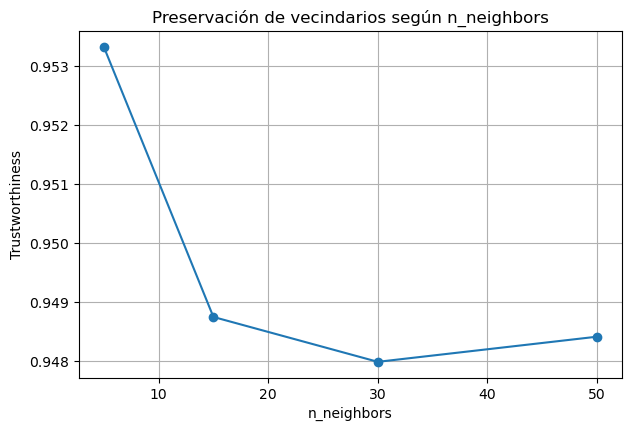

In [25]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    metricas_umap_neighbors['n_neighbors'],
    metricas_umap_neighbors['Trustworthiness'],
    marker='o'
)

plt.xlabel('n_neighbors')
plt.ylabel('Trustworthiness')
plt.title('Preservación de vecindarios según n_neighbors')
plt.grid(True)
plt.show()


In [26]:
trust_min_dist = []

for d in valores_min_dist:
    embedding_eval = resultados_umap_min_dist[d][posiciones_eval]

    valor = trustworthiness(
        X_eval,
        embedding_eval,
        n_neighbors=10
    )

    trust_min_dist.append(valor)

metricas_umap_min_dist['Trustworthiness'] = trust_min_dist
metricas_umap_min_dist


,min_dist,Tiempo (s),Trustworthiness
0,0.0,11.450918,0.952389
1,0.1,11.949910,0.948750
2,0.5,11.782797,0.932200
3,0.9,11.828450,0.915041


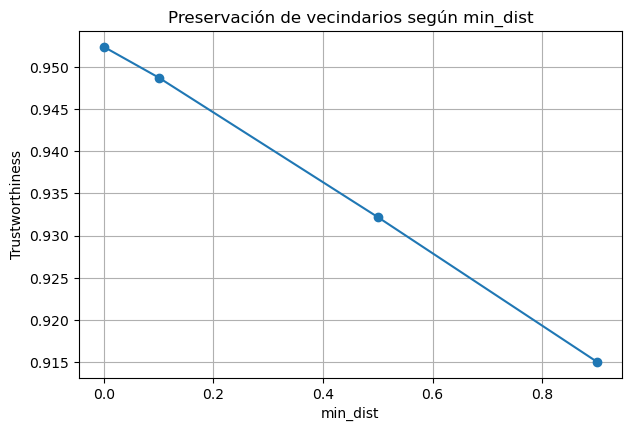

In [27]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    metricas_umap_min_dist['min_dist'],
    metricas_umap_min_dist['Trustworthiness'],
    marker='o'
)

plt.xlabel('min_dist')
plt.ylabel('Trustworthiness')
plt.title('Preservación de vecindarios según min_dist')
plt.grid(True)
plt.show()


## 10. Comparación entre t-SNE y UMAP

Para una comparación sencilla utilizaremos las configuraciones iniciales:

t-SNE con perplexity = 30

UMAP con n_neighbors = 15 y min_dist = 0.1

Compararemos el tiempo de ejecución y la preservación de vecindarios mediante trustworthiness.


In [28]:
trust_tsne_inicial = trustworthiness(
    X_eval,
    X_tsne.iloc[posiciones_eval].values,
    n_neighbors=10
)

trust_umap_inicial = trustworthiness(
    X_eval,
    X_umap.iloc[posiciones_eval].values,
    n_neighbors=10
)

comparacion = pd.DataFrame({
    'Método': ['t-SNE', 'UMAP'],
    'Configuración': [
        'perplexity=30',
        'n_neighbors=15, min_dist=0.1'
    ],
    'Tiempo (s)': [
        tiempo_tsne,
        tiempo_umap
    ],
    'Trustworthiness': [
        trust_tsne_inicial,
        trust_umap_inicial
    ]
})
comparacion

,Método,Configuración,Tiempo (s),Trustworthiness
0,t-SNE,perplexity=30,31.334641,0.960671
1,UMAP,"n_neighbors=15, min_dist=0.1",30.431948,0.948750


La comparación no debe basarse solamente en la separación visual de los grupos.

t-SNE y UMAP tienen funciones objetivo diferentes y pueden producir geometrías distintas.

Trustworthiness permite comparar la preservación local de vecindarios bajo una métrica común.

El tiempo de ejecución permite complementar el análisis desde el punto de vista computacional.

UMAP también puede utilizarse para obtener representaciones con más de dos dimensiones mediante n_components, por lo que su uso no se limita a la visualización bidimensional.
